# DSC602 — Information Visualization (Homework 1)

**Dataset:** Old cars (1970–1982)  
**Objectives:** basic visualization techniques + Matplotlib familiarity

This notebook:
- Loads and cleans the dataset
- Performs basic exploratory data analysis (EDA)
- Implements **Task 1–Task 4** exactly as stated in the assignment


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 1) Load data

In [3]:
# Try common local paths first
CANDIDATE_PATHS = [
    "old_cars - old_cars.csv",
    os.path.join(".", "old_cars - old_cars.csv"),
    os.path.join("assignment", "DSC602", "old_cars - old_cars.csv"),
]

csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'old_cars - old_cars.csv'. "
        "Place the CSV next to this notebook or update CANDIDATE_PATHS."
    )

df = pd.read_csv(csv_path)
csv_path, df.shape

('old_cars - old_cars.csv', (398, 7))

### Quick preview

In [4]:
df.head(10)

,Car,MPG,Displacement,Horsepower,Weight,Model,Origin
0,AMC Ambassador Brougham,13.0,360.0,175,3821,73,US
1,AMC Ambassador DPL,15.0,390.0,190,3850,70,US
2,AMC Ambassador SST,17.0,304.0,150,3672,72,US
3,AMC Concord,19.4,232.0,90,3210,78,US
4,AMC Concord,24.3,151.0,90,3003,80,US
5,AMC Concord d/l,18.1,258.0,120,3410,78,US
6,AMC Concord DL,23.0,151.0,0,3035,82,US
7,AMC Concord DL 6,20.2,232.0,90,3265,79,US
8,AMC Gremlin,21.0,199.0,90,2648,70,US
9,AMC Gremlin,19.0,232.0,100,2634,71,US


## 2) Data cleaning + typing

The dataset should have columns:
- `Car` (string)
- `MPG`, `Displacement`, `Horsepower`, `Weight` (numeric)
- `Model` (year, numeric)
- `Origin` (categorical: US / Europe / Japan)

Common issue in this dataset: some `Horsepower` values are **0** (often used as missing). We treat `Horsepower == 0` as missing.

In [5]:
df = df.copy()

# Standardize column names (just in case)
df.columns = [c.strip() for c in df.columns]

# Convert numeric columns
numeric_cols = ["MPG", "Displacement", "Horsepower", "Weight", "Model"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Treat 0 horsepower as missing (dataset convention)
df.loc[df["Horsepower"] == 0, "Horsepower"] = np.nan

# Clean up categories
df["Origin"] = df["Origin"].astype(str).str.strip()
df["Car"] = df["Car"].astype(str).str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car           398 non-null    object 
 1   MPG           398 non-null    float64
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    int64  
 5   Model         398 non-null    int64  
 6   Origin        398 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 21.9+ KB


### Missing values

In [6]:
df.isna().sum().sort_values(ascending=False)

Horsepower      6
MPG             0
Car             0
Displacement    0
Weight          0
Model           0
Origin          0
dtype: int64

### Summary statistics

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car,398,301,Toyota Corolla,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MPG,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6
Displacement,398.0,NaN,NaN,NaN,193.425879,104.269838,68.0,104.25,148.5,262.0,455.0
Horsepower,392.0,NaN,NaN,NaN,104.469388,38.49116,46.0,75.0,93.5,126.0,230.0
Weight,398.0,NaN,NaN,NaN,2970.424623,846.841774,1613.0,2223.75,2803.5,3608.0,5140.0
Model,398.0,NaN,NaN,NaN,76.01005,3.697627,70.0,73.0,76.0,79.0,82.0
Origin,398,3,US,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Distribution sanity checks

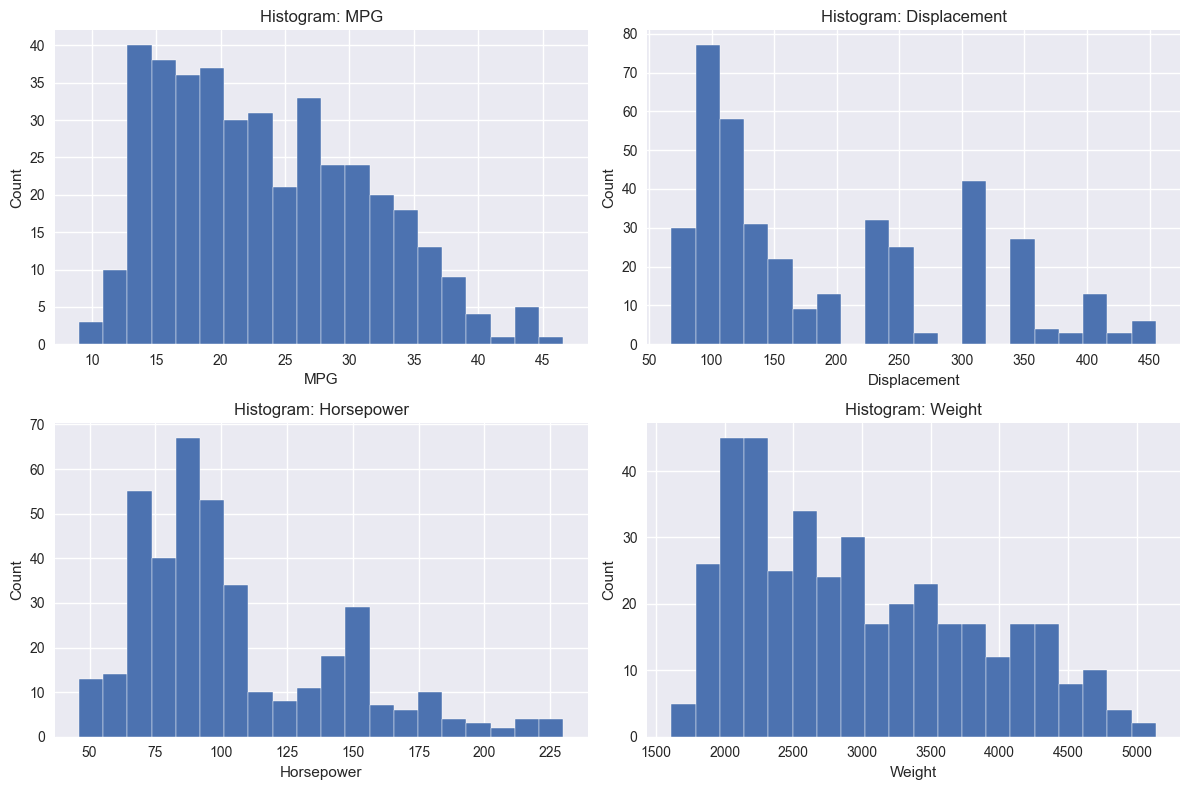

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

cols = ["MPG", "Displacement", "Horsepower", "Weight"]
for ax, c in zip(axes, cols):
    ax.hist(df[c].dropna(), bins=20, color="#4C72B0", edgecolor="white")
    ax.set_title(f"Histogram: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Task 1: Grouped bar chart MPG distribution by Origin (2 MPG increments)

**Requirement:** Discretize MPG values into **2-MPG** bins. For each MPG bin, show **3 bars** (US, Europe, Japan) so distributions compare across origins.

**Approach:**
- Build bins from `min(MPG)` to `max(MPG)` in steps of 2
- Use `pd.cut` to assign each car to a bin
- Count cars per bin per origin
- Plot grouped bars with offsets

In [9]:
mpg = df["MPG"].dropna()

# Build 2-MPG increment bins
min_mpg = np.floor(mpg.min() / 2) * 2
max_mpg = np.ceil(mpg.max() / 2) * 2
bins = np.arange(min_mpg, max_mpg + 2, 2)

df_task1 = df.dropna(subset=["MPG", "Origin"]).copy()
df_task1["MPG_bin"] = pd.cut(df_task1["MPG"], bins=bins, right=False)

# Count per bin and origin
counts = (
    df_task1.groupby(["MPG_bin", "Origin"])  
    .size()
    .unstack(fill_value=0)
)

# Ensure consistent origin order
origin_order = [o for o in ["US", "Europe", "Japan"] if o in counts.columns]
counts = counts.reindex(columns=origin_order)

counts.head()

C:\Users\GROUP\AppData\Local\Temp\ipykernel_1772\4274231642.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_task1.groupby(["MPG_bin", "Origin"])


Origin,US,Europe,Japan
MPG_bin,,,
"[8.0, 10.0)",1,0,0
"[10.0, 12.0)",6,0,0
"[12.0, 14.0)",26,0,0
"[14.0, 16.0)",41,0,0
"[16.0, 18.0)",30,3,0


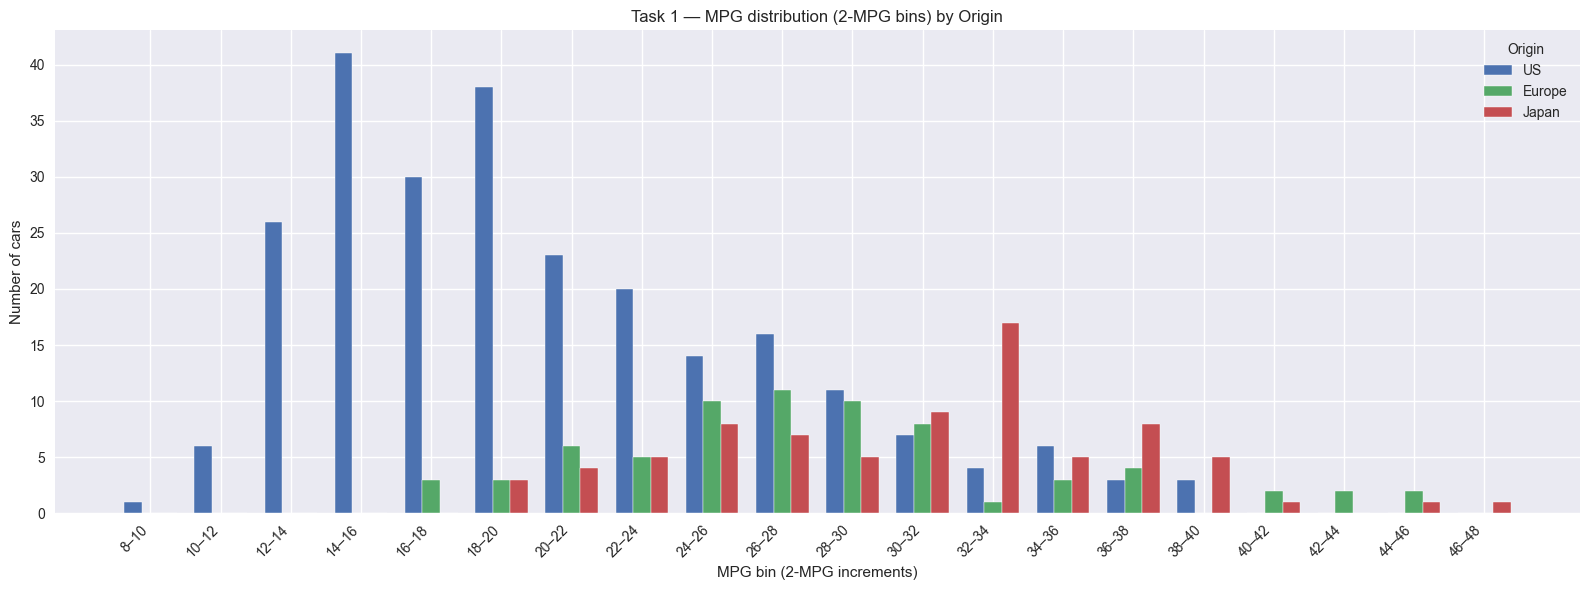

In [10]:
x = np.arange(len(counts.index))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

colors = {"US": "#4C72B0", "Europe": "#55A868", "Japan": "#C44E52"}

for i, origin in enumerate(origin_order):
    ax.bar(
        x + (i - (len(origin_order) - 1) / 2) * bar_width,
        counts[origin].values,
        width=bar_width,
        label=origin,
        color=colors.get(origin, None),
        edgecolor="white",
    )

ax.set_title("Task 1 — MPG distribution (2-MPG bins) by Origin")
ax.set_xlabel("MPG bin (2-MPG increments)")
ax.set_ylabel("Number of cars")

# Make readable bin labels
bin_labels = [f"{int(iv.left)}–{int(iv.left+2)}" for iv in counts.index]
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")

ax.legend(title="Origin")
plt.tight_layout()
plt.show()

## Task 2: Line chart evolution of average MPG (1970–1982) by Origin

**Requirement:** For each origin, plot **annual average MPG** from **1970 to 1982** (13 points per curve), with different colors.

In [11]:
df_task2 = df.dropna(subset=["MPG", "Model", "Origin"]).copy()
df_task2 = df_task2[(df_task2["Model"] >= 70) & (df_task2["Model"] <= 82)]

avg_mpg = (
    df_task2.groupby(["Model", "Origin"])  
    ["MPG"].mean()
    .unstack()
)

# Ensure all years 70..82 are present (even if missing for an origin)
years = np.arange(70, 83)
avg_mpg = avg_mpg.reindex(years)
avg_mpg = avg_mpg.reindex(columns=origin_order)

avg_mpg.head()

Origin,US,Europe,Japan
Model,,,
70,15.272727,25.20,25.500000
71,18.100000,28.75,29.500000
72,16.277778,22.00,24.200000
73,15.034483,24.00,20.000000
74,18.333333,27.00,29.333333


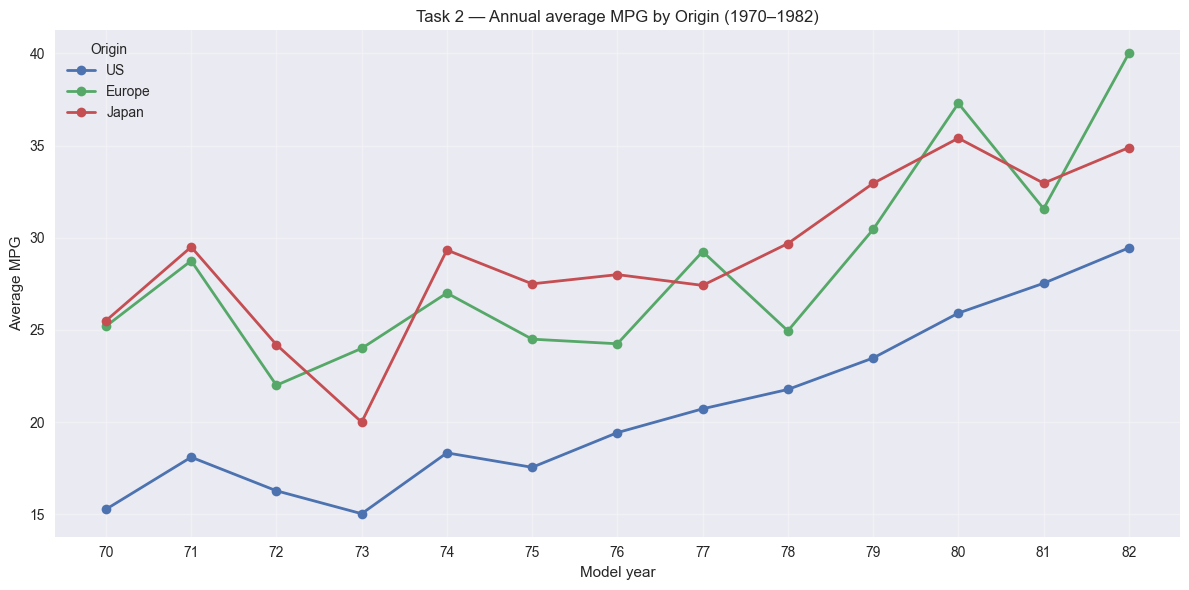

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

for origin in origin_order:
    ax.plot(
        years,
        avg_mpg[origin],
        marker="o",
        linewidth=2,
        label=origin,
        color=colors.get(origin, None),
    )

ax.set_title("Task 2 — Annual average MPG by Origin (1970–1982)")
ax.set_xlabel("Model year")
ax.set_ylabel("Average MPG")
ax.set_xticks(years)
ax.legend(title="Origin")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 3: Scatter plot Horsepower vs MPG (color = year)

**Requirement:**
- x-axis: `Horsepower`
- y-axis: `MPG`
- each point: a car
- color coding: `Model` year

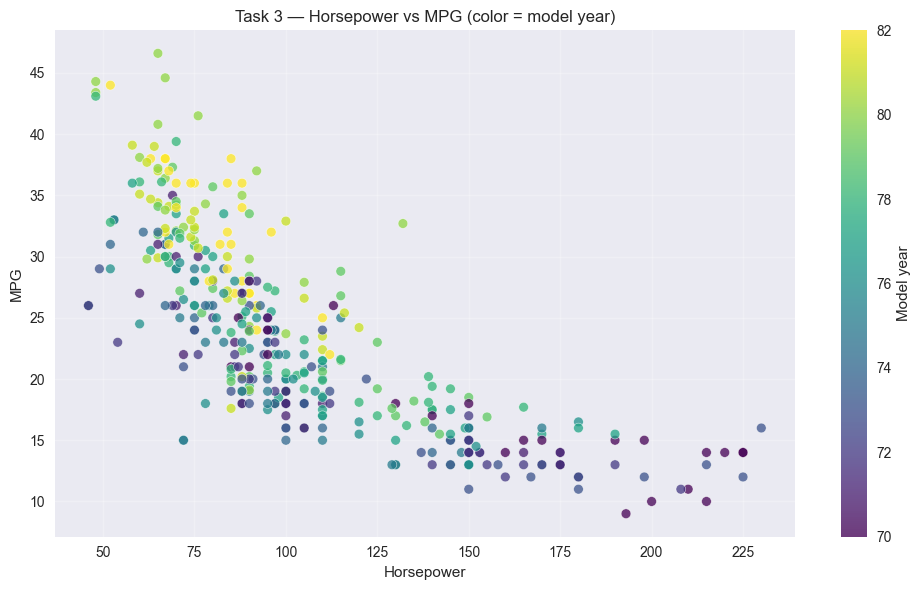

In [13]:
df_task3 = df.dropna(subset=["Horsepower", "MPG", "Model"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_task3["Horsepower"],
    df_task3["MPG"],
    c=df_task3["Model"],
    cmap="viridis",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4,
)

ax.set_title("Task 3 — Horsepower vs MPG (color = model year)")
ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.grid(True, alpha=0.25)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Model year")

plt.tight_layout()
plt.show()

## Task 4: Scatter plot matrix MPG, Weight, Horsepower, Displacement (color = Origin)

**Requirement:** Use a scatter plot matrix for:
- `MPG`, `Weight`, `Horsepower`, `Displacement`

Color code data points by `Origin`.



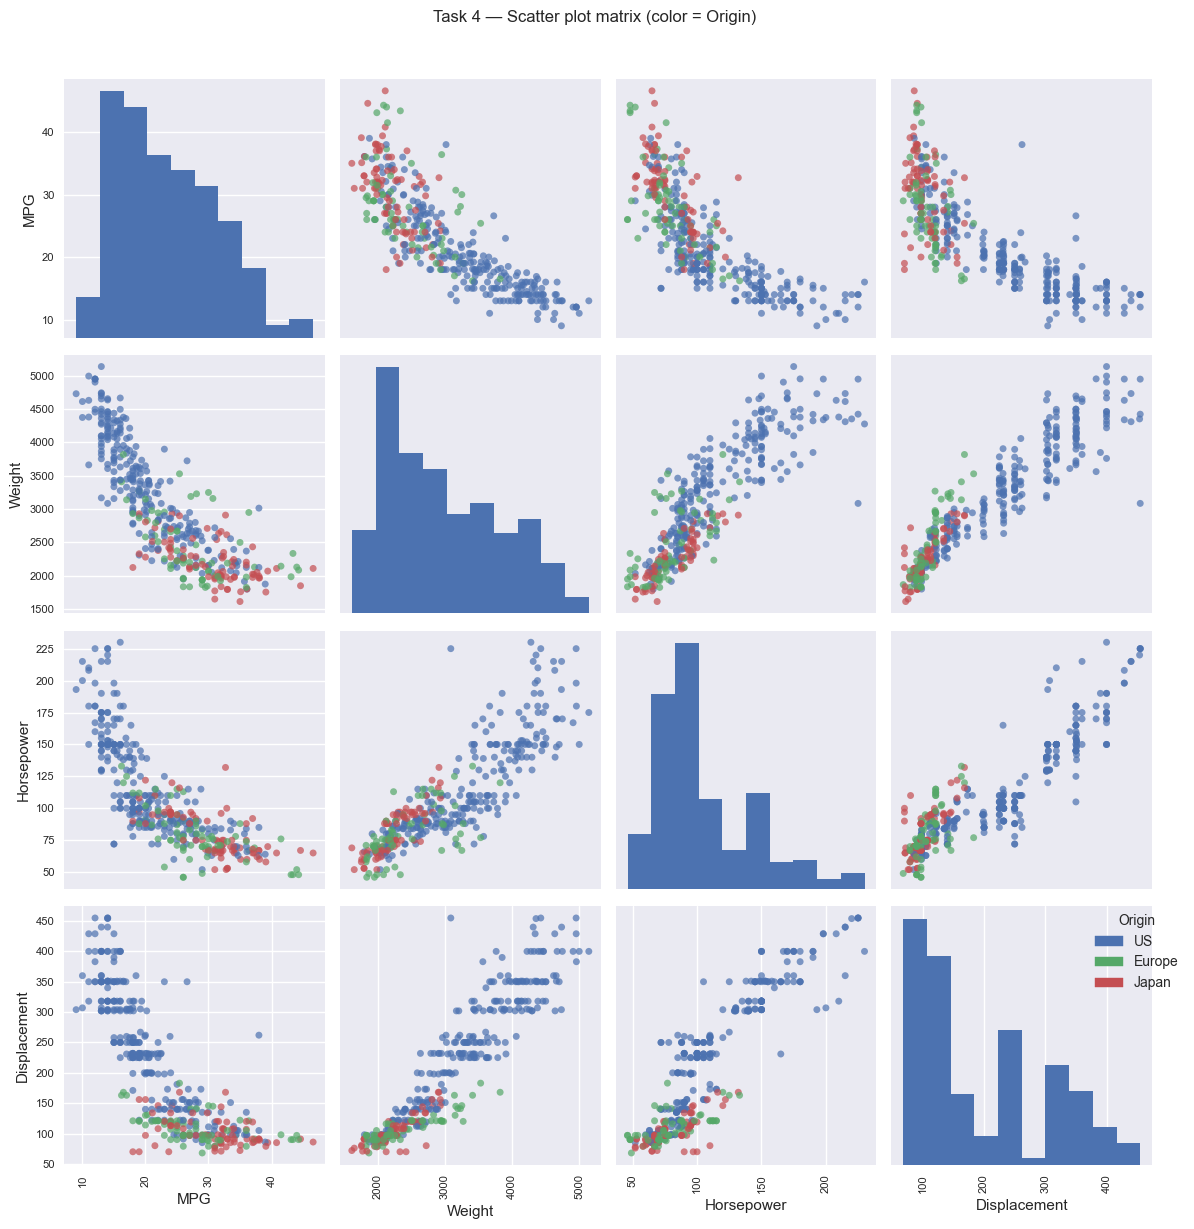

In [14]:
cols_matrix = ["MPG", "Weight", "Horsepower", "Displacement"]
df_task4 = df.dropna(subset=cols_matrix + ["Origin"]).copy()

# Map origins to colors for scatter_matrix
origin_to_color = {"US": "#4C72B0", "Europe": "#55A868", "Japan": "#C44E52"}
point_colors = df_task4["Origin"].map(origin_to_color).fillna("#777777")

axes = scatter_matrix(
    df_task4[cols_matrix],
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.7,
    c=point_colors,
    marker="o",
    s=25,
    range_padding=0.1,
)

# Add a custom legend (scatter_matrix doesn't add it automatically)
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color=origin_to_color[o], label=o)
    for o in origin_order
    if o in df_task4["Origin"].unique()
]

plt.suptitle("Task 4 — Scatter plot matrix (color = Origin)", y=1.02)
plt.legend(handles=legend_handles, title="Origin", loc="upper right", bbox_to_anchor=(1.15, 1.02))

plt.tight_layout()
plt.show()